In [1]:
!pip install optuna

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
import math
import gc
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error,r2_score, mean_absolute_percentage_error)
optuna.logging.set_verbosity(optuna.logging.WARNING)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [3]:
df = pd.read_csv("/teamspace/studios/this_studio/Nigeria/Nigeria_Rainfall_Nigeria_Rainfall_43y.csv")
df

,date,adm_level,adm_id,PCODE,n_pixels,rfh,rfh_avg,r1h,r1h_avg,r3h,r3h_avg,rfq,r1q,r3q,version,month,dekad
0,1996-01-11,2,22905,463,87.0,1.275862,1.459387,3.988506,4.769349,105.494260,65.188510,97.158790,92.007225,157.425000,final,1,11
1,1996-01-21,2,22905,463,87.0,2.172414,2.067433,4.655172,4.973180,24.471264,18.145977,101.485420,96.811360,127.327800,final,1,21
2,1996-02-01,2,22905,463,87.0,3.137931,1.965900,6.586207,5.492721,13.954022,14.613793,116.825260,110.421390,96.636185,final,2,1
3,1996-02-11,2,22905,463,87.0,3.126437,3.331034,8.436781,7.364368,15.827587,16.782759,97.544136,108.673410,95.615010,final,2,11
4,1996-02-21,2,22905,463,87.0,3.850575,3.834100,10.114943,9.131035,19.344828,20.318008,100.186490,106.962740,96.156170,final,2,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1189579,2025-11-11,2,1000319,673,18.0,91.888885,59.822224,308.333300,246.294450,923.888900,931.725950,149.468640,124.687720,99.163360,final,11,11
1189580,2025-11-21,2,1000319,673,18.0,62.111110,38.762962,274.777770,164.966660,953.500000,843.574100,153.351410,164.607440,112.954185,final,11,21
1189581,2025-12-01,2,1000319,673,18.0,97.277780,24.766666,251.277770,123.351850,955.611000,745.681460,343.598360,199.668150,127.965200,final,12,1
1189582,2025-12-11,2,1000319,673,18.0,17.888890,8.933333,177.277770,72.462970,813.944400,636.168500,164.274320,235.309570,127.726850,final,12,11


In [4]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

df = df.sort_values(['PCODE','year','month','dekad']).reset_index(drop=True)
df.columns

Index(['date', 'adm_level', 'adm_id', 'PCODE', 'n_pixels', 'rfh', 'rfh_avg',
       'r1h', 'r1h_avg', 'r3h', 'r3h_avg', 'rfq', 'r1q', 'r3q', 'version',
       'month', 'dekad', 'year'],
      dtype='object')

In [5]:
DROP_COLS = [
    'date', 'adm_level', 'adm_id', 'n_pixels', 'rfh_avg', 'r1h_avg',  'r3h_avg', 'rfq', 'r1q', 'r3q', 'version'
]
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
df = df.sort_values(['PCODE','year','month','dekad']).reset_index(drop=True)
print(f'Raw shape: {df.shape}')
df.head(10)

Raw shape: (1189584, 7)


,PCODE,rfh,r1h,r3h,month,dekad,year
0,0,22.0,30.0,282.5,1,1,1982
1,0,12.0,40.5,222.5,1,11,1982
2,0,26.5,60.5,143.0,1,21,1982
3,0,4.5,43.0,106.5,2,1,1982
4,0,9.5,40.5,95.0,2,11,1982
5,0,46.0,60.0,132.5,2,21,1982
6,0,42.5,98.0,171.0,3,1,1982
7,0,35.5,124.0,205.0,3,11,1982
8,0,56.5,134.5,255.0,3,21,1982
9,0,53.5,145.5,286.5,4,1,1982


In [6]:
# Lag features
for lag in [1, 2, 3, 6, 12]:
    df[f'rfh_lag_{lag}'] = df.groupby('PCODE')['rfh'].shift(lag)


# Encode PCODE
df['PCODE'] = df['PCODE'].astype('category').cat.codes
NUM_PCODES  = df['PCODE'].nunique()

# Cyclic time features
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['dekad_sin'] = np.sin(2 * np.pi * df['dekad'] / 3)
df['dekad_cos'] = np.cos(2 * np.pi * df['dekad'] / 3)

df = df.dropna().reset_index(drop=True)
print(f'df: {df.shape}, PCODEs: {NUM_PCODES}')
df.head()

df: (1180572, 16), PCODEs: 751


,PCODE,rfh,r1h,r3h,month,dekad,year,rfh_lag_1,rfh_lag_2,rfh_lag_3,rfh_lag_6,rfh_lag_12,month_sin,month_cos,dekad_sin,dekad_cos
0,0,82.0,176.5,420.0,5,1,1982,42.0,52.5,53.5,42.5,22.0,5.000000e-01,-0.866025,8.660254e-01,-0.5
1,0,52.5,176.5,463.0,5,11,1982,82.0,42.0,52.5,35.5,12.0,5.000000e-01,-0.866025,-8.660254e-01,-0.5
2,0,100.0,234.5,517.0,5,21,1982,52.5,82.0,42.0,56.5,26.5,5.000000e-01,-0.866025,-1.714506e-15,1.0
3,0,136.5,289.0,611.0,6,1,1982,100.0,52.5,82.0,53.5,4.5,1.224647e-16,-1.000000,8.660254e-01,-0.5
4,0,81.5,318.0,657.0,6,11,1982,136.5,100.0,52.5,52.5,9.5,1.224647e-16,-1.000000,-8.660254e-01,-0.5


In [7]:
train_df = df[df['year'] <= 2015]
val_df = df[(df['year'] > 2015) & (df['year'] <= 2020)]
test_df = df[df['year'] > 2020]

print("train:",(train_df.shape))
print("val:",(val_df.shape))
print("test:",(test_df.shape))

train: (910212, 16)
val: (135180, 16)
test: (135180, 16)


In [8]:
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

In [9]:
transform_cols = [
    'rfh', 'r1h', 'r3h',
    'rfh_lag_1', 'rfh_lag_2','rfh_lag_3', 'rfh_lag_6','rfh_lag_12'
]
# Apply Yeo–Johnson
pt = PowerTransformer(method='yeo-johnson')

train_df[transform_cols] = pt.fit_transform(train_df[transform_cols])
val_df[transform_cols] = pt.transform(val_df[transform_cols])
test_df[transform_cols] = pt.transform(test_df[transform_cols])

# Apply RobustScaler
scaler = RobustScaler()

train_df[transform_cols] = scaler.fit_transform(train_df[transform_cols])
val_df[transform_cols] = scaler.transform(val_df[transform_cols])
test_df[transform_cols] = scaler.transform(test_df[transform_cols])

In [10]:
FEATURES = [
    'rfh','r1h','r3h',
    'rfh_lag_1','rfh_lag_2','rfh_lag_3','rfh_lag_6','rfh_lag_12',
    'month_sin','month_cos','dekad_sin','dekad_cos',
    'month','dekad',
]
TARGET    = 'rfh'

In [11]:
FEATURES_CHECK = len(FEATURES)
print(f'Features: {FEATURES_CHECK}, Target: {TARGET}')

Features: 14, Target: rfh


In [12]:
def create_sequences_per_pcode(df, features, target, seq_len=36):
    X_list, y_list, pcode_list = [], [], []
    
    for pcode, group in df.groupby('PCODE'):
        group = group.sort_values(['year','month','dekad'])
        
        X = group[features].values
        y = group[target].values
        
        for i in range(len(group) - seq_len):
            X_list.append(X[i:i+seq_len])
            y_list.append(y[i+seq_len])
            pcode_list.append(pcode)
    
    return (
        torch.tensor(X_list, dtype=torch.float32),
        torch.tensor(y_list, dtype=torch.float32),
        torch.tensor(pcode_list, dtype=torch.long)
    )

In [13]:
X_train, y_train, p_train = create_sequences_per_pcode(train_df, FEATURES, TARGET, seq_len=24)
X_val, y_val, p_val       = create_sequences_per_pcode(val_df, FEATURES, TARGET, seq_len=24)
X_test, y_test, p_test    = create_sequences_per_pcode(test_df, FEATURES, TARGET, seq_len=24)

/tmp/ipykernel_15224/3931648931.py:16: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  torch.tensor(X_list, dtype=torch.float32),


In [14]:
train_ds = TensorDataset(X_train, y_train, p_train)
val_ds   = TensorDataset(X_val, y_val, p_val)
test_ds  = TensorDataset(X_test, y_test, p_test)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=256, shuffle=False, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False, pin_memory=True)

In [15]:
class iTransformer(nn.Module):
    def __init__(self, num_features, seq_len, num_pcodes, d_model=128, n_heads=4, num_layers=3, d_ff=256, dropout=0.1, pcode_embed_dim=16):
        super().__init__()

        # 1. PCODE embedding
        self.pcode_emb = nn.Embedding(num_pcodes, pcode_embed_dim)
        # 2. Inverted embedding (Time - Representation)
        self.value_embedding = nn.Linear(seq_len, d_model)
        # 3. Feature (token) embedding
        self.feature_embedding = nn.Parameter(torch.randn(1, num_features, d_model))
        # 4. Combine dim
        self.total_dim = d_model + pcode_embed_dim

        # 5. Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.total_dim,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,
            activation='gelu'
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)

        # 6. LayerNorm
        self.norm = nn.LayerNorm(self.total_dim)

        # 7. Prediction head
        self.head = nn.Sequential(
            nn.Linear(self.total_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x, pcode):
        # x: (B, T, F)

        B, T, F = x.shape

        # 1. Invert → (B, F, T)
        x = x.permute(0, 2, 1)

        # 2. Project time → representation
        x = self.value_embedding(x)  # (B, F, d_model)

        # 3. Add feature embedding (VERY IMPORTANT - paper detail)
        x = x + self.feature_embedding

        # 4. PCODE embedding
        p_emb = self.pcode_emb(pcode)  # (B, E)
        p_emb = p_emb.unsqueeze(1).expand(-1, F, -1)

        # 5. Concatenate
        x = torch.cat([x, p_emb], dim=-1)

        # 6. Normalize
        x = self.norm(x)

        # 7. Transformer (attention across FEATURES)
        x = self.encoder(x)

        # 8. Aggregation (mean over features)
        x = x.mean(dim=1)

        # 9. Prediction
        out = self.head(x)

        return out.squeeze()

In [16]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for X, y, p in loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        p = p.to(device, non_blocking=True)

        optimizer.zero_grad()
        out = model(X, p)
        loss = criterion(out, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    

    with torch.no_grad():
        for X, y, p in loader:
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            p = p.to(device, non_blocking=True)

            out = model(X, p)
            loss = criterion(out, y)

            total_loss += loss.item()

    return total_loss / len(loader)

def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    

    with torch.no_grad():
        for X, y, p in loader:
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            p = p.to(device, non_blocking=True)

            out = model(X, p)
            loss = criterion(out, y)

            total_loss += loss.item()

    return total_loss / len(loader)

In [17]:
def objective(trial):

    # Search space 
    d_model = trial.suggest_categorical("d_model", [64, 128, 256])
    n_heads = trial.suggest_categorical("n_heads", [2, 4, 8])
    num_layers = trial.suggest_int("num_layers", 2, 4)
    d_ff = trial.suggest_categorical("d_ff", [128, 256, 512])
    dropout = trial.suggest_float("dropout", 0.1, 0.3)
    pcode_embed_dim = trial.suggest_categorical("pcode_embed_dim", [8, 16, 32])
    lr = trial.suggest_float("lr", 1e-4, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)

    total_dim = d_model + pcode_embed_dim
    if total_dim % n_heads != 0:
        raise optuna.exceptions.TrialPruned()

    # Model
    model = iTransformer(
        num_features=len(FEATURES),
        seq_len=24,
        num_pcodes=NUM_PCODES,
        d_model=d_model,
        n_heads=n_heads,
        num_layers=num_layers,
        d_ff=d_ff,
        dropout=dropout,
        pcode_embed_dim=pcode_embed_dim
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    best_val = float("inf")
    patience = 5
    patience_counter = 0

    # Training loop
    for epoch in range(10):  

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss   = validate(model, val_loader, criterion)

        trial.report(val_loss, epoch)
        
        # Check pruning BEFORE early-stopping break
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        # Early stopping
        if val_loss < best_val:
            best_val = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

        # Pruning (Optuna magic )
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_val

In [18]:
study = optuna.create_study(direction="minimize")

study.optimize(objective, n_trials=20)

print("Best Trial:")
print(study.best_trial.params)

Best Trial:
{'d_model': 128, 'n_heads': 8, 'num_layers': 4, 'd_ff': 128, 'dropout': 0.16867655723135877, 'pcode_embed_dim': 8, 'lr': 0.00011352898405756326, 'weight_decay': 5.004483043270571e-06}


In [19]:
best_params = study.best_trial.params

model = iTransformer(
    num_features=len(FEATURES),
    seq_len=24,
    num_pcodes=NUM_PCODES,
    d_model=best_params["d_model"],
    n_heads=best_params["n_heads"],
    num_layers=best_params["num_layers"],
    d_ff=best_params["d_ff"],
    dropout=best_params["dropout"],
    pcode_embed_dim=best_params["pcode_embed_dim"]
).to(device)

optimizer = torch.optim.AdamW( model.parameters(), lr=best_params["lr"], weight_decay=best_params["weight_decay"])

criterion = nn.MSELoss()

In [20]:
best_val = float("inf")
patience = 10
patience_counter = 0

for epoch in range(50):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss   = validate(model, val_loader, criterion)

    print(f"Epoch {epoch+1:02d} | Train {train_loss:.4f} | Val {val_loss:.4f}")

    if val_loss < best_val:
        best_val = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_itransformer.pth")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

Epoch 01 | Train 0.0339 | Val 0.0293
Epoch 02 | Train 0.0286 | Val 0.0294
Epoch 03 | Train 0.0273 | Val 0.0296
Epoch 04 | Train 0.0260 | Val 0.0305
Epoch 05 | Train 0.0243 | Val 0.0336
Epoch 06 | Train 0.0226 | Val 0.0360
Epoch 07 | Train 0.0211 | Val 0.0366
Epoch 08 | Train 0.0198 | Val 0.0367
Epoch 09 | Train 0.0187 | Val 0.0386
Epoch 10 | Train 0.0178 | Val 0.0385
Epoch 11 | Train 0.0170 | Val 0.0362
Early stopping at epoch 11


In [21]:
model.load_state_dict(torch.load("best_itransformer.pth", map_location=device))  
model.eval()

preds, actuals = [], []

with torch.no_grad():
    for X, y, p in test_loader:
        X = X.to(device)
        p = p.to(device)

        out = model(X, p)

        preds.append(out.cpu().numpy())
        actuals.append(y.numpy())

preds   = np.concatenate(preds).flatten()
actuals = np.concatenate(actuals).flatten()

In [22]:
rmse = np.sqrt(mean_squared_error( actuals, preds))
mae  = mean_absolute_error(actuals, preds)
r2   = r2_score(actuals, preds)

print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

RMSE: 0.18591408
MAE : 0.13509506
R2  : 0.8799399649809441


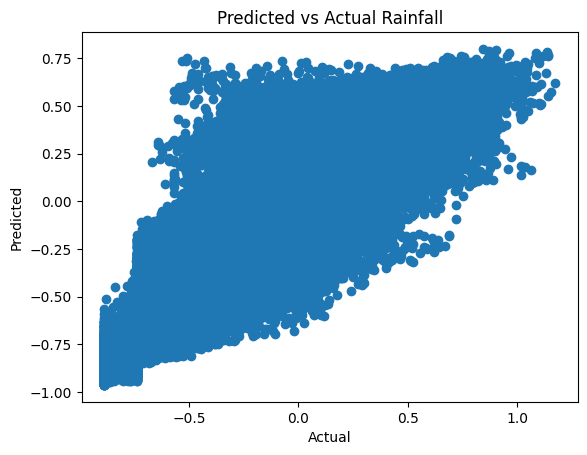

In [23]:
plt.figure()
plt.scatter(actuals, preds)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual Rainfall")
plt.show()

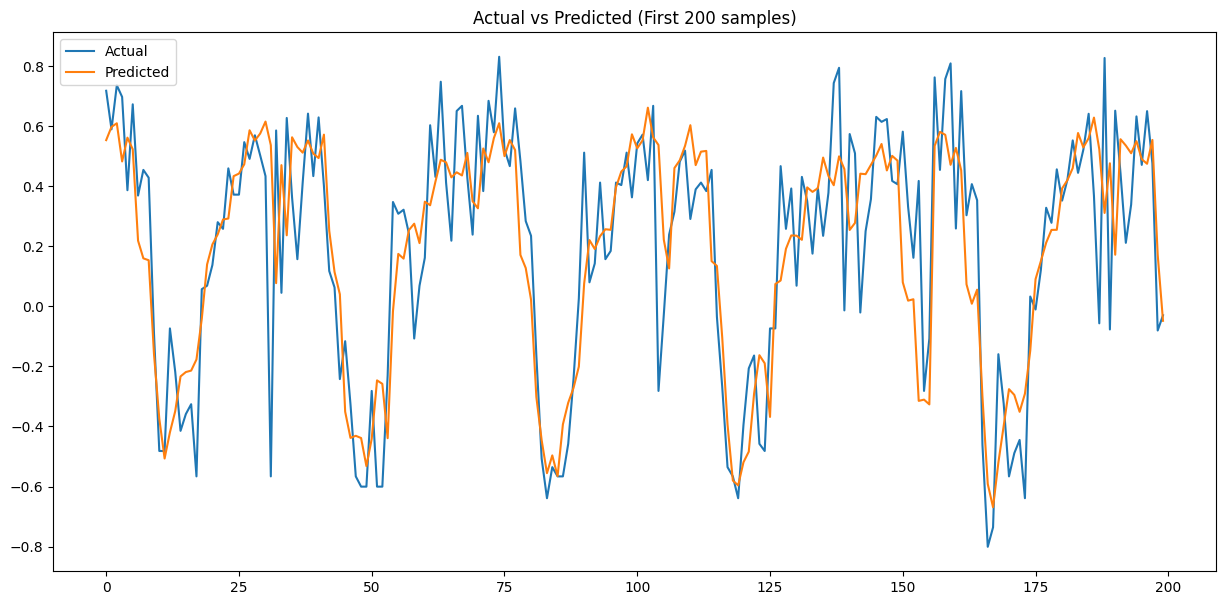

In [24]:
plt.figure(figsize=(15, 7))
plt.plot(actuals[:200], label="Actual")
plt.plot(preds[:200], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted (First 200 samples)")
plt.show()

In [25]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
import numpy as np


def evaluate(model, data_loader, label, device):
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for xb, yb, pb in data_loader:

            xb = xb.to(device)
            yb = yb.to(device)
            pb = pb.to(device)

            pred = model(xb, pb)

            all_preds.extend(
                pred.view(-1).cpu().numpy()
            )

            all_targets.extend(
                yb.view(-1).cpu().numpy()
            )

    # Convert to numpy arrays
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    # Metrics
    rmse = np.sqrt(
        mean_squared_error(
            all_targets,
            all_preds
        )
    )

    mae = mean_absolute_error(
        all_targets,
        all_preds
    )

    r2 = r2_score(
        all_targets,
        all_preds
    )

    print(f'{label}')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  MAE  : {mae:.4f}')
    print(f'  R²   : {r2:.4f}')

    return all_preds, rmse, mae, r2

In [26]:
y_train_pred, *_ = evaluate(
    model,
    train_loader,
    'TRAIN',
    device
)

print()

y_val_pred, *_ = evaluate(
    model,
    val_loader,
    'VALIDATION',
    device
)

print()

y_test_pred, *_ = evaluate(
    model,
    test_loader,
    'TEST',
    device
)

TRAIN
  RMSE : 0.1657
  MAE  : 0.1216
  R²   : 0.9043

VALIDATION
  RMSE : 0.1712
  MAE  : 0.1251
  R²   : 0.8991

TEST
  RMSE : 0.1859
  MAE  : 0.1351
  R²   : 0.8799


In [27]:
print(model)

iTransformer(
  (pcode_emb): Embedding(751, 8)
  (value_embedding): Linear(in_features=24, out_features=128, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=136, out_features=136, bias=True)
        )
        (linear1): Linear(in_features=136, out_features=128, bias=True)
        (dropout): Dropout(p=0.16867655723135877, inplace=False)
        (linear2): Linear(in_features=128, out_features=136, bias=True)
        (norm1): LayerNorm((136,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((136,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.16867655723135877, inplace=False)
        (dropout2): Dropout(p=0.16867655723135877, inplace=False)
      )
    )
  )
  (norm): LayerNorm((136,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(
    (0): Linear(in_features=136, out_feat